In [2]:
# ## MD ## MD ## MD ## MD ## MD ## MD ## MD ## MD ## MD ## MD ## MD ## MD 
# import os
# import glob
# import datetime
# import numpy as np
# import torch
# import random

# from ase import units
# from ase.io import read, write
# from ase.md.nose_hoover_chain import NoseHooverChainNVT
# from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
# from mace.calculators import MACECalculator
# from ase.data import covalent_radii, atomic_numbers
# from ase.constraints import Hookean

# # ==========================================
# # 1. 시뮬레이션 설정 (Configuration)
# # ==========================================
# seed_value = 2026
# random.seed(seed_value)
# np.random.seed(seed_value)
# torch.manual_seed(seed_value)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(seed_value)

# # 모델 및 경로 설정
# model_path = "/home/kyunghun/00_cu_interface/99_archieve/02_mace/mace-mh-1.model"
# device = "cuda" if torch.cuda.is_available() else "cpu"

# # MD 파라미터
# temperature_K = 1200
# timestep_fs = 2.0
# nvt_steps = 1001
# log_interval = 10
# nvt_tdamp_fs = 100

# # Hookean 제약 조건 파라미터
# hookean_tolerance = 0.5  
# hookean_k = 10.0         
# rt_offset = 0.2          

# if not hasattr(units, 'ps'):
#     units.ps = 1000 * units.fs

# base_dir = os.path.abspath(".")

# # ==========================================
# # 2. Helper 함수 정의
# # ==========================================

# # [개선 2] 현재 궤적(atoms_to_constrain)과 초기 기준 구조(atoms_for_reference)를 분리하여 받음
# def apply_hookean_constraints(atoms_to_constrain, atoms_for_reference, k_val, tolerance, rt_extra):
#     r_al = covalent_radii[atomic_numbers['Al']]
#     r_o  = covalent_radii[atomic_numbers['O']]
#     bond_cutoff = r_al + r_o + tolerance
#     rt_val = bond_cutoff + rt_extra

#     try:
#         chain_ids = atoms_for_reference.get_array('chain_id')
#     except KeyError:
#         print("경고: 'chain_id' 배열이 존재하지 않습니다. 폴백 모드로 동작합니다.")
#         chain_ids = [0] * len(atoms_for_reference)

#     al_indices = [atom.index for atom in atoms_for_reference if atom.symbol == 'Al']
#     o_indices = [atom.index for atom in atoms_for_reference if atom.symbol == 'O']

#     constraints = []
#     hookean_pairs = [] 
    
#     for i in al_indices:
#         for j in o_indices:
#             if chain_ids[i] > 0 and chain_ids[i] == chain_ids[j]:
#                 # 페어(결합) 여부는 변형되지 않은 '원본 기준 구조'의 거리를 바탕으로 판단
#                 dist = atoms_for_reference.get_distance(i, j, mic=True)
                
#                 if dist <= bond_cutoff:
#                     constraints.append(Hookean(a1=i, a2=j, k=k_val, rt=rt_val))
#                     hookean_pairs.append((i, j))
    
#     # 묶어줄 페어가 결정되면, 실제 MD를 수행할 구조(현재 프레임)에 제약 조건 적용
#     atoms_to_constrain.set_constraint(constraints)
#     return hookean_pairs

# def prepare_simulation(stage_name, target_steps, initial_atoms_path, input_stem):
#     extxyz_filename = f"{input_stem}_{stage_name}.extxyz"
    
#     if os.path.exists(extxyz_filename):
#         try:
#             history = read(extxyz_filename, index=":")
#             steps_already_done = max(0, (len(history) - 1) * log_interval)
#             if steps_already_done >= target_steps:
#                 return history[-1], 0, steps_already_done, 'a'
#             return history[-1], target_steps - steps_already_done, steps_already_done, 'a'
#         except:
#             pass
    
#     atoms = read(initial_atoms_path)
#     return atoms, target_steps, 0, 'w'

# def attach_loggers(dyn, atoms, log_filename, extxyz_filename, file_mode, hookean_pairs, start_step=0, interval=100):
#     def write_extxyz():
#         atoms.write(extxyz_filename, format="extxyz", append=True)

#     dyn.attach(write_extxyz, interval=interval)
    
#     logfile = open(log_filename, file_mode)
#     if file_mode == 'w':
#         header = f"{'Step':>8}  {'Time(ps)':>12}  {'Temp(K)':>12}  {'Max_Al_O(A)':>15}  {'Timestamp':<19}\n"
#         logfile.write(header)
    
#     def log_status():
#         internal_step = dyn.get_number_of_steps()
#         if file_mode == 'a' and internal_step == 0: return
#         current_step = internal_step + start_step
#         current_time = (dyn.get_time() + (start_step * dyn.dt)) / units.ps
#         temperature = atoms.get_temperature()

#         max_dist = 0.0
#         if hookean_pairs:
#             distances = [atoms.get_distance(i, j, mic=True) for i, j in hookean_pairs]
#             max_dist = max(distances)
#         timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
#         log_line = f"{current_step:>8d}  {current_time:>12.4f}  {temperature:>12.2f}  {max_dist:>15.4f}  {timestamp}\n"
#         logfile.write(log_line)
#         logfile.flush()

#     dyn.attach(log_status, interval=interval)
#     return logfile

# # ==========================================
# # 3. 메인 실행 (Main Execution)
# # ==========================================
# print("Loading MACE Calculator...")
# calc = MACECalculator(model_paths=model_path, device=device, default_dtype="float64", head="omat_pbe")

# all_folders = sorted([
#     f for f in os.listdir(base_dir) 
#     if os.path.isdir(os.path.join(base_dir, f)) and f.startswith("structure_")
# ])

# mid_index = len(all_folders) // 2

# # # 상단
# # target_folders = all_folders[:mid_index] 
# # # 하단
# # target_folders = all_folders[mid_index:] 

# # All
# target_folders = all_folders[:]

# print(f"Targeting {len(target_folders)} folders: {target_folders}")

# for folder_idx, folder_name in enumerate(target_folders):
#     work_dir = os.path.join(base_dir, folder_name)
#     if not os.path.isdir(work_dir): continue
        
#     print(f"\nEntering Directory: {work_dir}")
#     try:
#         os.chdir(work_dir)
        
#         # [개선 1] _nvt 가 포함된 궤적 파일은 제외하고 순수 초기 구조 파일만 탐색
#         input_files = [f for f in glob.glob("structure_*.extxyz") if "_nvt" not in f]
#         if not input_files:
#             print("  -> 적절한 초기 구조 파일을 찾을 수 없습니다.")
#             continue
            
#         input_file_path = input_files[0]
#         input_stem = os.path.splitext(input_file_path)[0]
        
#         # 항상 고정된 원본 초기 구조를 별도로 읽어둠 (Hookean 페어 판별용)
#         initial_atoms = read(input_file_path)
        
#         atoms_nvt, steps_to_run_nvt, steps_done_nvt, mode_nvt = prepare_simulation(
#             "nvt", nvt_steps, input_file_path, input_stem
#         )
#         atoms_nvt.calc = calc
        
#         # [개선 2 적용] atoms_nvt에 제약을 걸되, 페어(짝) 판별은 initial_atoms 기준으로 수행
#         hookean_pairs = apply_hookean_constraints(atoms_nvt, initial_atoms, hookean_k, hookean_tolerance, rt_offset)
#         print(f"  -> Applied {len(hookean_pairs)} Hookean constraints (Al-O).")
        
#         if steps_done_nvt == 0:
#             # [개선 3] 각 폴더마다 고유한 시드 적용하여 통계적 앙상블 다양성 확보
#             unique_seed = seed_value + folder_idx
#             rng = np.random.default_rng(unique_seed)
#             MaxwellBoltzmannDistribution(atoms_nvt, temperature_K=temperature_K, rng=rng)
#             Stationary(atoms_nvt)
            
#         if steps_to_run_nvt > 0:
#             dyn_nvt = NoseHooverChainNVT(
#                 atoms_nvt,
#                 timestep=timestep_fs * units.fs,
#                 temperature_K=temperature_K,
#                 tdamp=nvt_tdamp_fs * units.fs
#             )
#             extxyz_out = f"{input_stem}_nvt.extxyz"
#             log_nvt = attach_loggers(
#                 dyn_nvt, atoms_nvt, 
#                 f"md_{input_stem}_nvt.log", 
#                 extxyz_out, 
#                 mode_nvt, 
#                 hookean_pairs, 
#                 start_step=steps_done_nvt, 
#                 interval=log_interval
#             )
#             dyn_nvt.run(steps=steps_to_run_nvt)
#             log_nvt.close()

#     except Exception as e:
#         print(f"  -> Error: {e}")
#     finally:
#         os.chdir(base_dir)

# print("\nAll tasks finished.")


총 11개의 구조에 대해 종합 분석을 시작합니다...
분석 진행 중: structure_000_c1.extxyz (x = 0.00)
분석 진행 중: structure_020_c1.extxyz (x = 0.20)
분석 진행 중: structure_040_c1.extxyz (x = 0.40)
분석 진행 중: structure_060_c1.extxyz (x = 0.60)
분석 진행 중: structure_080_c1.extxyz (x = 0.80)
분석 진행 중: structure_100_c1.extxyz (x = 1.00)
분석 진행 중: structure_120_c1.extxyz (x = 1.20)
분석 진행 중: structure_140_c1.extxyz (x = 1.40)
분석 진행 중: structure_160_c1.extxyz (x = 1.60)
분석 진행 중: structure_180_c1.extxyz (x = 1.80)
분석 진행 중: structure_200_c1.extxyz (x = 2.00)

[완료] 데이터 분석 완료. 시각화 자료를 생성합니다...


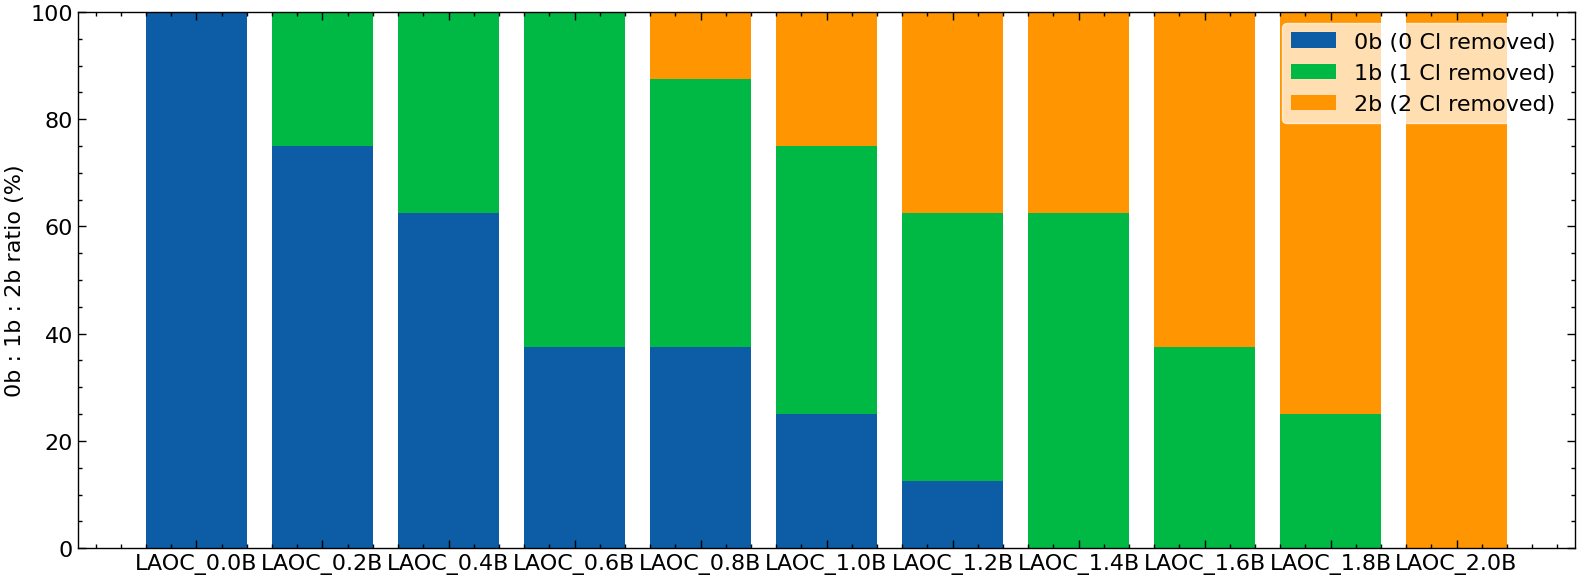

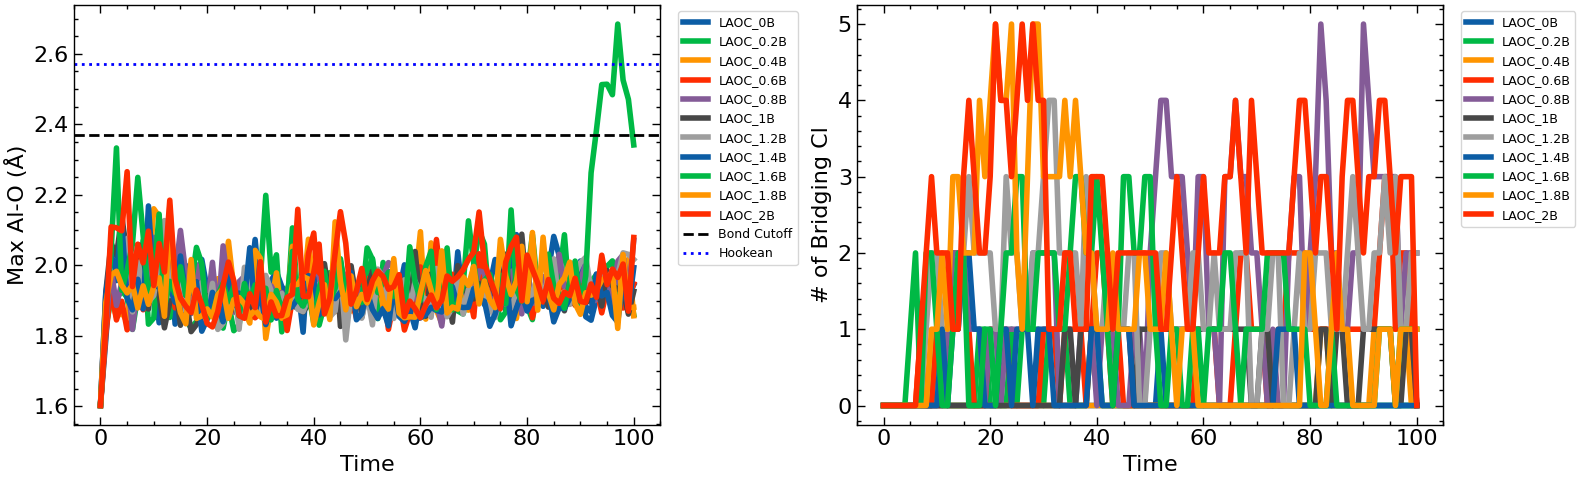

모든 작업이 완료되었습니다!
- 조성 데이터: composition_summary.csv / Figure1_Defect_Ratio.png
- MD 다이내믹스 그래프: Figure2_MD_Dynamics_Grid.png


In [1]:
## Analysis ## Analysis ## Analysis ## Analysis ## Analysis ## Analysis ## Analysis ## Analysis 
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from ase.io import read, write
from ase.neighborlist import neighbor_list
from ase.data import covalent_radii, atomic_numbers

# ==========================================
# 1. 설정 및 파라미터 
# ==========================================
# MD 계산에서 사용한 반경 및 Cutoff
r_al = covalent_radii[atomic_numbers['Al']]
r_o  = covalent_radii[atomic_numbers['O']]
r_cl = covalent_radii[atomic_numbers['Cl']]

AL_O_BOND_CUTOFF = r_al + r_o + 0.5    # 약 2.42 Å (파괴 기준선)
AL_O_HOOKEAN_RT  = AL_O_BOND_CUTOFF + 0.2  # 약 2.62 Å (복원력 시작선)
AL_CL_CUTOFF     = r_al + r_cl + 0.3   # 약 2.58 Å (Cl 결합 탐색선)

BASE_DIR = "mlmd_extxyz"

# 분석 대상 폴더 탐색
target_folders = sorted([f for f in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, f)) and f.startswith("structure_")])

# 데이터 저장을 위한 변수
composition_data = []
md_plot_data = {}

print(f"총 {len(target_folders)}개의 구조에 대해 종합 분석을 시작합니다...\n" + "="*60)

# ==========================================
# 2. 메인 분석 루프
# ==========================================
for folder in target_folders:
    base_name = folder.replace(".extxyz", "")
    traj_file = os.path.join(BASE_DIR, folder, f"{base_name}_nvt.extxyz")
    
    # x 값 추출 (예: structure_030_c1 -> 0.3)
    try:
        x_val = float(base_name.split('_')[1]) / 100.0
    except:
        x_val = 0.0
    
    if not os.path.exists(traj_file):
        continue
        
    print(f"분석 진행 중: {folder} (x = {x_val:.2f})")
    traj = read(traj_file, index=':')
    initial_atoms = traj[0]
    
    chain_ids = initial_atoms.get_array('chain_id')
    al_roles = initial_atoms.get_array('al_role')
    
    # ----------------------------------------------------
    # [목표 1] 초기 구조 결함 분포 (0b, 1b, 2b) 분석
    # ----------------------------------------------------
    cl_i, al_j = neighbor_list('ij', initial_atoms, {('Cl', 'Al'): AL_CL_CUTOFF})
    mid_al_indices = [i for i, role in enumerate(al_roles) if role == 1]
    
    counts = {0: 0, 1: 0, 2: 0} # 2 Cls(0b), 1 Cl(1b), 0 Cl(2b)
    
    for al_idx in mid_al_indices:
        # 이 중앙 Al에 결합된 Cl의 개수 파악
        attached_cls = sum(1 for a in al_j if a == al_idx)
        if attached_cls == 2:
            counts[0] += 1 # 0 broken
        elif attached_cls == 1:
            counts[1] += 1 # 1 broken
        else:
            counts[2] += 1 # 2 broken
            
    total_mid_al = len(mid_al_indices)
    composition_data.append({
        'x_val': x_val,
        'Folder': folder,
        '0b_Count': counts[0],
        '1b_Count': counts[1],
        '2b_Count': counts[2],
        '0b_Ratio(%)': (counts[0]/total_mid_al)*100 if total_mid_al else 0,
        '1b_Ratio(%)': (counts[1]/total_mid_al)*100 if total_mid_al else 0,
        '2b_Ratio(%)': (counts[2]/total_mid_al)*100 if total_mid_al else 0,
    })

    # ----------------------------------------------------
    # [목표 2 & 3] 체인 유지 검증 및 브릿징 품질 분석
    # ----------------------------------------------------
    # 체인 내 초기 Al-O 쌍 식별
    ini_i, ini_j = neighbor_list('ij', initial_atoms, AL_O_BOND_CUTOFF)
    chain_bonds = [(i, j) for i, j in zip(ini_i, ini_j) if i < j and chain_ids[i] == chain_ids[j] and chain_ids[i] > 0 and {initial_atoms[i].symbol, initial_atoms[j].symbol} == {'Al', 'O'}]

    frames, max_dists, bridge_counts, avg_deltas = [], [], [], []
    best_bridge_frames = [] # (품질 점수, 프레임 번호, atoms)

    for f_idx, atoms in enumerate(traj):
        frames.append(f_idx)
        
        # 1. 최대 Al-O 거리 (Hookean)
        max_dist = max([atoms.get_distance(i, j, mic=True) for i, j in chain_bonds]) if chain_bonds else 0
        max_dists.append(max_dist)
        
        # 2. 브릿징 품질 분석
        c_i, a_j = neighbor_list('ij', atoms, {('Cl', 'Al'): AL_CL_CUTOFF})
        cl_to_al = {}
        for c, a in zip(c_i, a_j):
            if atoms[c].symbol == 'Cl':
                cl_to_al.setdefault(c, []).append(a)
                
        frame_bridge_count = 0
        frame_deltas = []
        best_delta_in_frame = float('inf')
        best_mu_in_frame = float('inf')

        for cl_idx, al_indices in cl_to_al.items():
            if len(al_indices) == 2:
                a1, a2 = al_indices
                c1, c2 = chain_ids[a1], chain_ids[a2]
                r1, r2 = al_roles[a1], al_roles[a2]
                
                # 동일 체인 내에서 중앙 Al(1)과 양끝 Al(2)을 잇는 경우
                if c1 == c2 and c1 > 0 and {r1, r2} == {1, 2}:
                    frame_bridge_count += 1
                    d1 = atoms.get_distance(cl_idx, a1, mic=True)
                    d2 = atoms.get_distance(cl_idx, a2, mic=True)
                    
                    delta = abs(d1 - d2)   # 분산 대용 (비대칭도)
                    mu = (d1 + d2) / 2.0   # 평균 결합 길이
                    
                    frame_deltas.append(delta)
                    
                    # 가장 대칭적(delta 낮음)이고 타이트한(mu 낮음) 결합 추적
                    if delta < best_delta_in_frame:
                        best_delta_in_frame = delta
                        best_mu_in_frame = mu
                        
        bridge_counts.append(frame_bridge_count)
        avg_deltas.append(np.mean(frame_deltas) if frame_deltas else np.nan)
        
        if frame_bridge_count > 0:
            # 품질 점수: 비대칭도가 낮을수록(0에 가까울수록), 결합길이가 짧을수록 좋음
            score = best_delta_in_frame + (0.1 * best_mu_in_frame)
            best_bridge_frames.append((score, best_delta_in_frame, best_mu_in_frame, f_idx, atoms))

    md_plot_data[x_val] = {
        'frames': frames, 'max_dists': max_dists, 
        'bridge_counts': bridge_counts, 'avg_deltas': avg_deltas
    }

# ==========================================
# 3. 데이터 저장 및 시각화 (Figure 1: 결함 비율)
# ==========================================
print("\n[완료] 데이터 분석 완료. 시각화 자료를 생성합니다...")

# CSV 저장
df_comp = pd.DataFrame(composition_data)

# 데이터가 비어있지 않은 경우에만 정렬 실행
if not df_comp.empty:
    df_comp = df_comp.sort_values(by='x_val')

df_comp.to_csv("composition_summary.csv", index=False)

# Figure 1: 누적 막대 그래프
with plt.style.context(["science", "notebook"]):
    fig1, ax1 = plt.subplots(figsize=(16, 6))
    x_labels = [f"LAOC_{x:.1f}B" for x in df_comp['x_val']]
    bar_0b = df_comp['0b_Ratio(%)'].values
    bar_1b = df_comp['1b_Ratio(%)'].values
    bar_2b = df_comp['2b_Ratio(%)'].values

    ax1.bar(x_labels, bar_0b, label='0b (0 Cl removed)', color='C0')
    ax1.bar(x_labels, bar_1b, bottom=bar_0b, label='1b (1 Cl removed)', color='C1')
    ax1.bar(x_labels, bar_2b, bottom=bar_0b + bar_1b, label='2b (2 Cl removed)', color='C2')

    # ax1.set_xlabel("Global Composition (x)")
    ax1.set_ylabel("0b : 1b : 2b ratio (%)")
    
    # [수정됨] 범례를 그래프 안쪽 우측 상단에 배치하고, 배경을 반투명(alpha=0.7)하게 설정
    ax1.legend(loc='upper right', frameon=True, framealpha=0.7, edgecolor='white')
    
    plt.tight_layout()
    plt.show()
    fig1.savefig("Figure1_Defect_Ratio.png", dpi=300)

# ==========================================
# 4. 데이터 시각화 (Figure 2: MD 궤적 Subplot)
# ==========================================
num_plots = len(md_plot_data)
if num_plots > 0:
    with plt.style.context(["science", "notebook"]):
        # [수정됨] 범례가 들어갈 공간을 확보하기 위해 가로 길이를 16으로 약간 늘림
        fig2, axs = plt.subplots(1, 2, figsize=(16, 5))

        sorted_x_vals = sorted(md_plot_data.keys())

        for idx, x_val in enumerate(sorted_x_vals):
            data = md_plot_data[x_val]
            fr = data['frames']
            
            # [수정됨] 라벨 이름 변경 (예: x=0.2 -> LAOC_0.2b)
            # ':g' 포맷을 사용하면 0.20의 불필요한 0을 지워 0.2로 깔끔하게 출력합니다.
            label_name = f'LAOC_{x_val:g}B' 

            # Col 0, Col 1 플롯 그리기
            axs[0].plot(fr, data['max_dists'], label=label_name, linewidth=4)
            axs[1].plot(fr, data['bridge_counts'], label=label_name, linewidth=4)

        # Cutoff 라인은 플롯에 한 번만 추가
        axs[0].axhline(y=AL_O_BOND_CUTOFF, color='black', linestyle='--', label='Bond Cutoff')#, alpha=0.5
        axs[0].axhline(y=AL_O_HOOKEAN_RT, color='blue', linestyle=':', label='Hookean')#, alpha=0.5

        # 첫 번째 그래프 축 설정
        # axs[0].set_title("1. Chain Stability (Max Al-O)")
        axs[0].set_ylabel("Max Al-O (Å)")
        axs[0].set_xlabel("Time")
        # [수정됨] 범례를 그래프 우측 바깥으로 이동
        axs[0].legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True) 

        # 두 번째 그래프 축 설정
        # axs[1].set_title("2. Intra-Chain Bridging Cl Count")
        axs[1].set_ylabel("# of Bridging Cl")
        axs[1].set_xlabel("Time")
        # [수정됨] 범례를 그래프 우측 바깥으로 이동
        axs[1].legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)

        plt.tight_layout()
        plt.show()
        
        # [수정됨] 바깥으로 빠진 범례가 이미지 저장 시 잘리지 않도록 bbox_inches='tight' 추가
        fig2.savefig("Figure2_MD_Dynamics_Grid.png", dpi=300, bbox_inches='tight')

print("모든 작업이 완료되었습니다!")
print("- 조성 데이터: composition_summary.csv / Figure1_Defect_Ratio.png")
print("- MD 다이내믹스 그래프: Figure2_MD_Dynamics_Grid.png")

데이터 추출 및 시각화 시작 (대상 파일: 11개)
분석 중: ./mlmd_extxyz/structure_000_c1.extxyz/structure_000_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(1), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_020_c1.extxyz/structure_020_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_040_c1.extxyz/structure_040_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(9), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_060_c1.extxyz/structure_060_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_080_c1.extxyz/structure_080_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_100_c1.extxyz/structure_100_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_120_c1.extxyz/structure_120_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_140_c1.extxyz/structure_140_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중:

<Figure size 800x600 with 0 Axes>

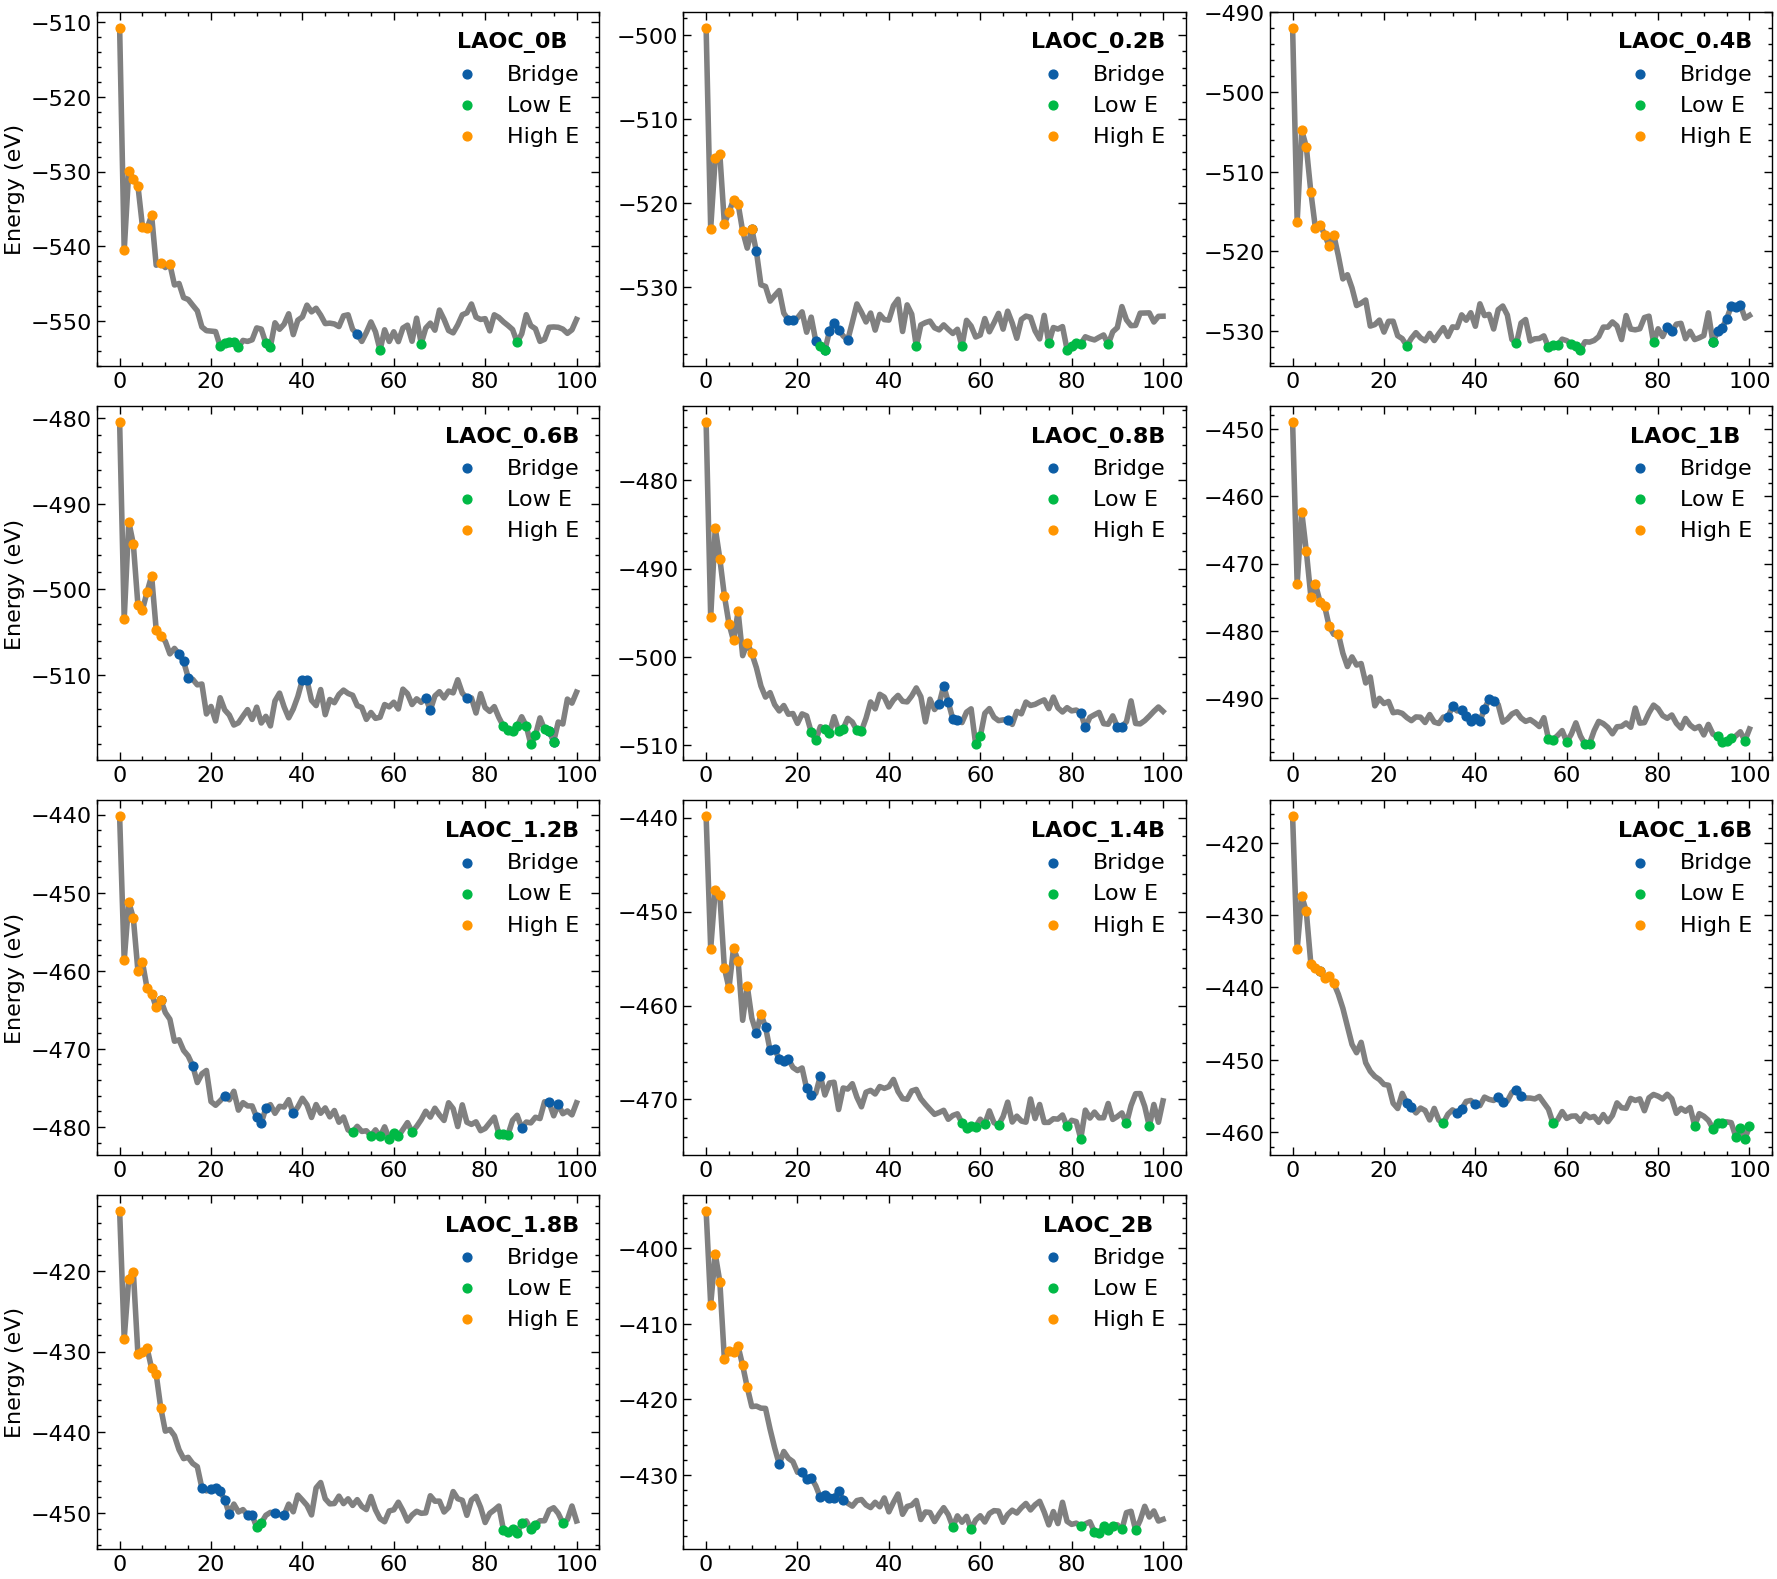


[체크] 모든 구조의 에너지 분포가 ./Figure3_extract.png에 통합 저장되었습니다.


In [12]:
## Extract ## Extract ## Extract ## Extract ## Extract ## Extract 
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from ase.io import read, write
from ase.neighborlist import neighbor_list
from ase.data import covalent_radii, atomic_numbers

# ==========================================
# 1. 설정 및 파라미터
# ==========================================
# Al-Cl 결합 판단 기준 (MD 코드와 동일하게 설정)
r_al = covalent_radii[atomic_numbers['Al']]
r_cl = covalent_radii[atomic_numbers['Cl']]
AL_CL_CUTOFF = r_al + r_cl + 0.3 

RUN_DIR = "."
BASE_DIR = "./mlmd_extxyz"
MAIN_OUTPUT_DIR = "../02_mlmd_extract/finetuning_dataset" # 병합된 최상위 저장 폴더

# 추출할 구조 개수 설정
MAX_BRIDGE_SAMPLES = 10
MAX_LOW_ENERGY_SAMPLES = 10
MAX_HIGH_ENERGY_SAMPLES = 10

# 분석할 궤적 파일 재귀적 탐색
traj_files = sorted(glob.glob(os.path.join(BASE_DIR, "**/*_nvt.extxyz"), recursive=True))

# --- 전체 시각화를 위한 설정 추가 ---
n_files = len(traj_files)
ncols = 3
nrows = (n_files + ncols - 1) // ncols  # 11개일 경우 4행 생성

with plt.style.context(["science", "notebook"]):
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
    axes_flat = axes.flatten()

    def get_bridging_cl_count(atoms):
        """현재 프레임에서 Intra-chain Bridging Cl의 개수를 반환 (01_analysis.py 로직 동기화)"""
        # 체인 정보나 역할 정보가 없는 경우를 대비한 예외 처리
        if 'chain_id' not in atoms.arrays or 'al_role' not in atoms.arrays:
            return 0

        chain_ids = atoms.get_array('chain_id')
        al_roles = atoms.get_array('al_role')
        cl_i, al_j = neighbor_list('ij', atoms, {('Cl', 'Al'): AL_CL_CUTOFF})

        cl_to_al = {}
        for c, a in zip(cl_i, al_j):
            if atoms[c].symbol == 'Cl':
                if c not in cl_to_al: cl_to_al[c] = []
                cl_to_al[c].append(a)

        count = 0
        for cl_idx, al_indices in cl_to_al.items():
            if len(al_indices) == 2:
                a1, a2 = al_indices
                c1, c2 = chain_ids[a1], chain_ids[a2]
                r1, r2 = al_roles[a1], al_roles[a2]

                # 동일 체인 내에서 중앙 Al(1)과 양끝 Al(2)을 잇는 경우만 브릿징으로 판별
                if c1 == c2 and c1 > 0 and {r1, r2} == {1, 2}:
                    count += 1
        return count

    def get_energy(atoms):
        """프레임의 에너지를 반환 (extxyz info field에서 추출)"""
        try:
            return atoms.get_potential_energy()
        except:
            return atoms.info.get('energy', 0.0)

    # ==========================================
    # 2. 메인 분석 및 추출 루프
    # ==========================================
    print(f"데이터 추출 및 시각화 시작 (대상 파일: {len(traj_files)}개)\n" + "="*60)

    for traj_file in traj_files:
        base_name = os.path.basename(traj_file).replace("_nvt.extxyz", "")
        folder = os.path.basename(os.path.dirname(traj_file))

        print(f"분석 중: {traj_file} ...")
        try:
            traj = read(traj_file, index=':')
        except Exception as e:
            print(f"  -> 파일 읽기 실패: {e}")
            continue
        
        frame_data = []
        all_indices = []
        all_energies = []

        for idx, atoms in enumerate(traj):
            b_count = get_bridging_cl_count(atoms)
            energy = get_energy(atoms)

            frame_data.append({
                'index': idx,
                'bridge_count': b_count,
                'energy': energy,
                'atoms': atoms
            })

            # 플롯팅을 위한 전체 데이터 저장
            all_indices.append(idx)
            all_energies.append(energy)

        # --- 선별 전략 1: Bridging Cl이 많은 순서 ---
        bridge_candidates = [f for f in frame_data if f['bridge_count'] > 0]
        bridge_candidates.sort(key=lambda x: x['bridge_count'], reverse=True)
        selected_bridge = bridge_candidates[:MAX_BRIDGE_SAMPLES]

        # --- 선별 전략 2: 에너지가 낮은 순서 ---
        energy_sorted = sorted(frame_data, key=lambda x: x['energy'])
        selected_low_energy = energy_sorted[:MAX_LOW_ENERGY_SAMPLES]

        # --- 선별 전략 3: 에너지가 높은 순서 ---
        selected_high_energy = energy_sorted[-MAX_HIGH_ENERGY_SAMPLES:]
        selected_high_energy.reverse() # 가장 높은 에너지가 먼저 오도록 정렬

        # --- 파일 저장 루프 ---
        to_save = [
            (selected_bridge, "bridge"),
            (selected_low_energy, "low_energy"),
            (selected_high_energy, "high_energy")
        ]

        for dataset, feature_name in to_save:
            for item in dataset:
                f_idx = item['index']

                if feature_name == "bridge":
                    val = item['bridge_count']
                    feature_tag = f"f{f_idx}_bridge{int(val)}"
                elif feature_name == "low_energy":
                    val = item['energy']
                    feature_tag = f"f{f_idx}_lowEnergy_{val:.2f}"
                elif feature_name == "high_energy":
                    val = item['energy']
                    feature_tag = f"f{f_idx}_highEnergy_{val:.2f}"

                save_path = os.path.join(MAIN_OUTPUT_DIR, base_name, feature_name, feature_tag)
                os.makedirs(save_path, exist_ok=True)

                file_name = f"{feature_tag}.vasp"
                write(os.path.join(save_path, file_name), item['atoms'], format='vasp', vasp5=True, sort=True)

        print(f"  -> 추출 완료: Bridging({len(selected_bridge)}), 저에너지({len(selected_low_energy)}), 고에너지({len(selected_high_energy)})")

        # ==========================================
        # 3. 데이터 시각화 (에너지 Plot 및 추출 지점 표시)
        # ==========================================
        # 각 추출 그룹별 x(index), y(energy) 좌표 분리
        bridge_idx = [item['index'] for item in selected_bridge]
        bridge_ene = [item['energy'] for item in selected_bridge]

        low_idx = [item['index'] for item in selected_low_energy]
        low_ene = [item['energy'] for item in selected_low_energy]

        high_idx = [item['index'] for item in selected_high_energy]
        high_ene = [item['energy'] for item in selected_high_energy]

        # ==========================================
        # 3. 데이터 시각화 (Subplot 각 칸에 그리기)
        # ==========================================
        ax = axes_flat[traj_files.index(traj_file)] # 현재 순서에 맞는 subplot 선택

        # 데이터 분리
        bridge_idx = [item['index'] for item in selected_bridge]
        bridge_ene = [item['energy'] for item in selected_bridge]
        low_idx = [item['index'] for item in selected_low_energy]
        low_ene = [item['energy'] for item in selected_low_energy]
        high_idx = [item['index'] for item in selected_high_energy]
        high_ene = [item['energy'] for item in selected_high_energy]

        # 해당 칸(ax)에 그래프 작성
        ax.plot(all_indices, all_energies, color='gray', zorder=1, linewidth=4) #label='Trajectory',
        ax.scatter(bridge_idx, bridge_ene, color='C0', marker='o', s=40, label='Bridge')
        ax.scatter(low_idx, low_ene, color='C1', marker='o', s=40, label='Low E')
        ax.scatter(high_idx, high_ene, color='C2', marker='o', s=40, label='High E')
        # ax.set_xlabel('Time')

        x_str = base_name.split('_')[1]
        x_val = float(x_str) / 100.0
        custom_label = f"LAOC_{x_val:g}B" # :g는 0.20을 0.2로 깔끔하게 포맷팅해줍니다.

        ax.legend(title=custom_label, title_fontproperties={'weight':'bold'}, loc='best')
        # ax.legend(title=custom_label, title_fontproperties={'weight':'bold', 'size':9}, fontsize=8, loc='best')
        # ax.tick_params(axis='both', which='major', labelsize=8)
        if traj_files.index(traj_file) % ncols == 0:
            ax.set_ylabel('Energy (eV)')

    # 사용하지 않는 빈 서브플롯 숨기기 (11개일 경우 마지막 한 칸)
    for j in range(n_files, len(axes_flat)):
        axes_flat[j].axis('off')
    plt.tight_layout()
    # 전체 요약 이미지 저장
    summary_plot_path = os.path.join(RUN_DIR, "Figure3_extract.png")
    plt.show()
    plt.savefig(summary_plot_path, dpi=300)
    print(f"\n[체크] 모든 구조의 에너지 분포가 {summary_plot_path}에 통합 저장되었습니다.")

In [ ]:
# ## Extract ## Extract ## Extract ## Extract ## Extract ## Extract 

# import os
# import numpy as np
# from ase.io import read, write
# from ase.neighborlist import neighbor_list
# from ase.data import covalent_radii, atomic_numbers

# # ==========================================
# # 1. 설정 및 파라미터
# # ==========================================
# # Al-Cl 결합 판단 기준 (MD 코드와 동일하게 설정)
# r_al = covalent_radii[atomic_numbers['Al']]
# r_cl = covalent_radii[atomic_numbers['Cl']]
# AL_CL_CUTOFF = r_al + r_cl + 0.3 

# BASE_DIR = "./mlmd_extxyz"
# MAIN_OUTPUT_DIR = "../02_mlmd_extract/finetuning_dataset" # 병합된 최상위 저장 폴더

# # 추출할 구조 개수 설정
# MAX_BRIDGE_SAMPLES = 10
# MAX_LOW_ENERGY_SAMPLES = 10
# MAX_HIGH_ENERGY_SAMPLES = 10

# import glob
# # 분석할 궤적 파일 재귀적 탐색
# traj_files = sorted(glob.glob(os.path.join(BASE_DIR, "**/*_nvt.extxyz"), recursive=True))

# def get_bridging_cl_count(atoms):
#     """현재 프레임에서 Intra-chain Bridging Cl의 개수를 반환"""
#     # 체인 정보가 없는 경우를 대비한 예외 처리
#     if 'chain_id' not in atoms.arrays:
#         return 0
        
#     chain_ids = atoms.get_array('chain_id')
#     cl_i, al_j = neighbor_list('ij', atoms, {('Cl', 'Al'): AL_CL_CUTOFF})
    
#     cl_to_al = {}
#     for c, a in zip(cl_i, al_j):
#         if atoms[c].symbol == 'Cl':
#             if c not in cl_to_al: cl_to_al[c] = []
#             cl_to_al[c].append(a)
    
#     count = 0
#     for cl_idx, al_indices in cl_to_al.items():
#         if len(al_indices) == 2:
#             c1, c2 = chain_ids[al_indices[0]], chain_ids[al_indices[1]]
#             if c1 == c2 and c1 > 0:
#                 count += 1
#     return count

# def get_energy(atoms):
#     """프레임의 에너지를 반환 (extxyz info field에서 추출)"""
#     try:
#         return atoms.get_potential_energy()
#     except:
#         return atoms.info.get('energy', 0.0)

# # ==========================================
# # 2. 메인 분석 및 추출 루프
# # ==========================================
# print(f"데이터 추출 시작 (대상 파일: {len(traj_files)}개)\n")

# for traj_file in traj_files:
#     base_name = os.path.basename(traj_file).replace("_nvt.extxyz", "")
#     folder = os.path.basename(os.path.dirname(traj_file))

#     print(f"분석 중: {traj_file} ...")
#     try:
#         traj = read(traj_file, index=':')
#     except Exception as e:
#         print(f"  -> 파일 읽기 실패: {e}")
#         continue
    
#     frame_data = []
#     for idx, atoms in enumerate(traj):
#         b_count = get_bridging_cl_count(atoms)
#         energy = get_energy(atoms)
#         frame_data.append({
#             'index': idx,
#             'bridge_count': b_count,
#             'energy': energy,
#             'atoms': atoms
#         })

#     # --- 선별 전략 1: Bridging Cl이 많은 순서 (상위 5개) ---
#     bridge_candidates = [f for f in frame_data if f['bridge_count'] > 0]
#     bridge_candidates.sort(key=lambda x: x['bridge_count'], reverse=True)
#     selected_bridge = bridge_candidates[:MAX_BRIDGE_SAMPLES]

#     # --- 선별 전략 2: 에너지가 낮은 순서 (상위 5개) ---
#     energy_sorted = sorted(frame_data, key=lambda x: x['energy'])
#     selected_low_energy = energy_sorted[:MAX_LOW_ENERGY_SAMPLES]

#     # --- 선별 전략 3: 에너지가 높은 순서 (상위 5개) ---
#     selected_high_energy = energy_sorted[-MAX_HIGH_ENERGY_SAMPLES:]
#     selected_high_energy.reverse() # 가장 높은 에너지가 먼저 오도록 정렬

#     # --- 파일 저장 루프 ---
#     to_save = [
#         (selected_bridge, "bridge"),
#         (selected_low_energy, "low_energy"),
#         (selected_high_energy, "high_energy")
#     ]

#     for dataset, feature_name in to_save:
#         for item in dataset:
#             f_idx = item['index']
            
#             # 특징 이름 생성 및 폴더명/파일명 지정
#             if feature_name == "bridge":
#                 val = item['bridge_count']
#                 feature_tag = f"f{f_idx}_bridge{int(val)}"
#             elif feature_name == "low_energy":
#                 val = item['energy']
#                 feature_tag = f"f{f_idx}_lowEnergy_{val:.2f}"
#             elif feature_name == "high_energy":
#                 val = item['energy']
#                 feature_tag = f"f{f_idx}_highEnergy_{val:.2f}"

#             # 최종 경로 설정: finetuning_dataset/structure_030_c1/bridge/f120_bridge3/f120_bridge3.vasp
#             save_path = os.path.join(MAIN_OUTPUT_DIR, base_name, feature_name, feature_tag)
#             if not os.path.exists(save_path):
#                 os.makedirs(save_path)
            
#             file_name = f"{feature_tag}.vasp"
#             write(os.path.join(save_path, file_name), item['atoms'], format='vasp', vasp5=True, sort=True)

#     print(f"  -> 추출 완료: Bridging({len(selected_bridge)}), 저에너지({len(selected_low_energy)}), 고에너지({len(selected_high_energy)})")

# print(f"\n모든 작업이 완료되었습니다. 결과 폴더: {MAIN_OUTPUT_DIR}")

데이터 추출 시작 (대상 파일: 11개)

분석 중: ./mlmd_extxyz/structure_000_c1.extxyz/structure_000_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(1), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_020_c1.extxyz/structure_020_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_040_c1.extxyz/structure_040_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(9), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_060_c1.extxyz/structure_060_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_080_c1.extxyz/structure_080_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_100_c1.extxyz/structure_100_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_120_c1.extxyz/structure_120_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중: ./mlmd_extxyz/structure_140_c1.extxyz/structure_140_c1_nvt.extxyz ...
  -> 추출 완료: Bridging(10), 저에너지(10), 고에너지(10)
분석 중: ./ml